In [128]:
# import packages
import pandas as pd
import numpy as np
import colorsys

import numpy.polynomial.polynomial as poly

import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

In [98]:
df_turbido = pd.read_csv('data/Turbidostat.csv')
df_turbido

,channel,decision,time_h,OD
0,1,145,297.2658,0.3343
1,1,145,297.3492,0.3338
2,1,145,297.4325,0.3318
3,1,145,297.5158,0.3338
4,1,145,297.5992,0.3318
...,...,...,...,...
1565,8,233,321.6831,0.3462
1566,8,233,321.7678,0.3475
1567,8,233,321.8497,0.3484
1568,8,233,321.9331,0.3479


In [13]:
print(df_turbido.channel.unique())

[1 3 4 5 7 8]


### Functions

In [ ]:
"""Random functions"""

# function for colours in the plot
def get_distinct_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        saturation = 0.65
        value = 0.85
        colors.append(colorsys.hsv_to_rgb(hue, saturation, value))
    return colors


### Transform data & fit function

In [ ]:
# create second dataframe and add transform the OD data
df_transform = df_turbido
df_transform["ODtrns"] = np.log(df_turbido["OD"])
df_transform

In [ ]:


df_coefs = pd.DataFrame(columns= ['channel', 'decision', 'int', 'slope'])

# for each decision, in each channel, 
for channel in df_transform.channel.unique():
    print(type(channel))
    df_channel = df_transform[df_transform.channel == channel]
    for decision in df_channel.decision.unique():
        df_decision = df_channel[df_channel.decision == decision]

        # we fit a linear function
        coefs = poly.polyfit(df_decision["time_h"], df_decision["ODtrns"], 1)
        
        # store the params
        df_coefs.loc[len(df_coefs)] = [int(channel), int(decision),  coefs[0] , coefs[1]]


df_coefs
# coefs = poly.polyfit(x, y, 1)
df_coefs = df_coefs.set_index(['channel', 'decision'])

df_coefs
# # linear = poly.Polynomial.fit(x, y, 1)

<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>


int     slope
channel decision                    
1.0     145.0    -4.914756  0.012806
        146.0    -4.323295  0.010672
        147.0    -3.834617  0.008931
        151.0    -5.524217  0.013663
3.0     118.0    -4.789712  0.011701
        119.0    -4.316531  0.010000
        121.0    -4.776729  0.011123
        122.0    -5.279635  0.012521
4.0     126.0    -5.010515  0.013041
        128.0    -5.626185  0.014664
        129.0    -5.361404  0.013628
        133.0    -5.527206  0.013540
5.0     303.0    -6.371376  0.013974
        304.0    -5.865957  0.012512
        305.0    -5.830702  0.012282
        306.0    -5.863311  0.012227
7.0     192.0    -2.931962  0.006263
        193.0    -3.934549  0.009371
        194.0    -4.301179  0.010321
        195.0    -4.610523  0.011101
8.0     230.0    -4.290159  0.010605
        231.0    -4.181531  0.010061
        232.0    -4.642224  0.011338
        233.0    -4.849252  0.011772

### Plot data

to do: Change the code so that each time it is just the last 'decision' value that is colour different.

In [123]:
df_transform["ODtrns"].iloc[-1]

np.float64(-1.049536451021517)

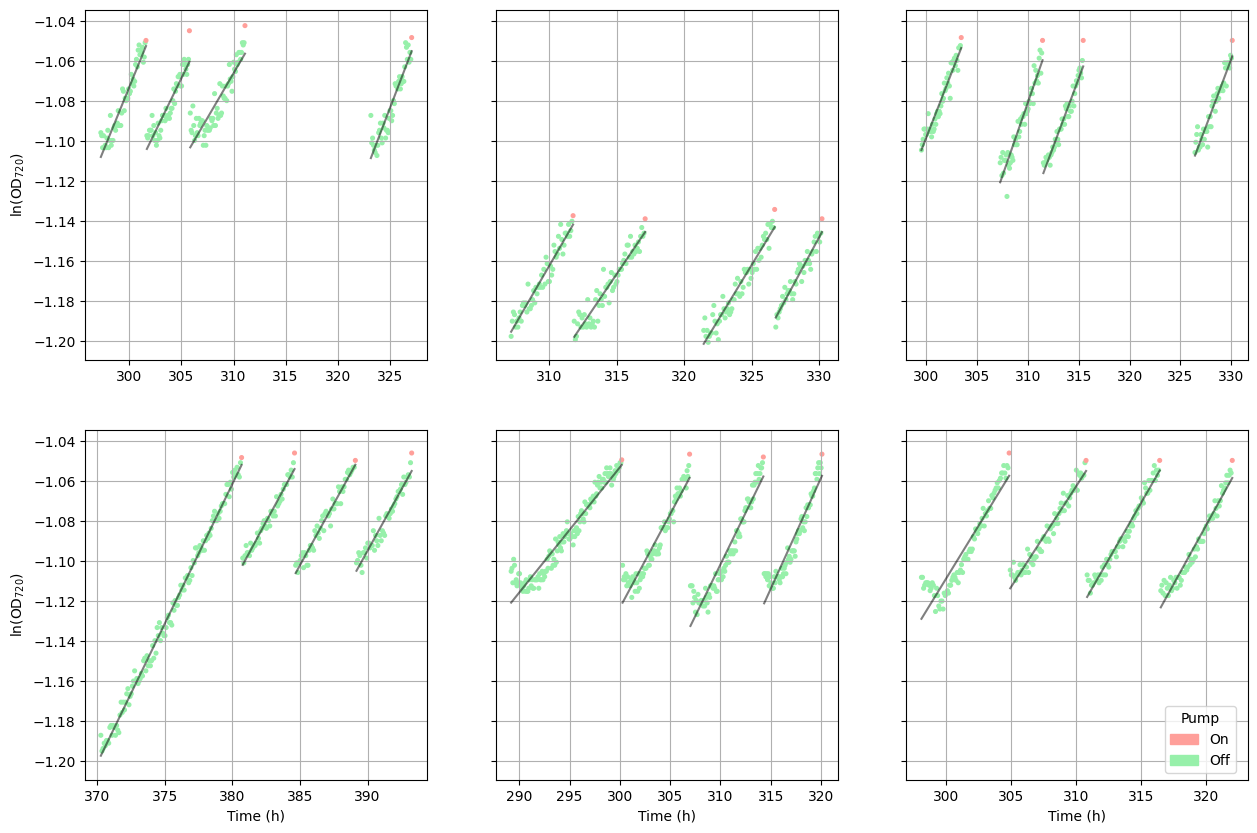

In [169]:
# Define fixed color mapping for all decision values

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
col_th = np.where(df_transform['decision'] != df_transform['decision'].shift(-1), colors[2], colors[1])

df_transform['col_th'] = col_th


fig, axs = plt.subplots(2, 3, sharex= False, sharey= True, figsize = (15, 10))
plt.grid()

for i, channel in enumerate(sorted(df_transform.channel.unique())):
    df_channel = df_transform[df_transform['channel'] == channel]

    row, col = divmod(i, 3)
    
    # plot the scatter and grid for each 
    axs[row, col].scatter(df_channel.time_h, df_channel.ODtrns, s = 7, c = df_channel.col_th)
    axs[row, col].grid(True)
    for decision in df_channel.decision.unique():
        df_decision = df_channel[df_channel['decision'] == decision]
        
        intercept = df_coefs.loc[(channel, decision), 'int']
        slope = df_coefs.loc[(channel, decision), 'slope']
        y = slope * df_decision.time_h + intercept

        axs[row, col].plot(df_decision.time_h, y, color = 'black', alpha = 0.5)

    if col == 0:
        axs[row, col].set_ylabel(r'ln(OD$_{720}$)')
    
    if row == 1:    
        axs[row, col].set_xlabel(f'Time (h)')
    

legend_patches = [mpatches.Patch(color=colors[2], label=f'On'), 
                  mpatches.Patch(color=colors[1], label=f'Off')]
fig.legend(handles=legend_patches, title='Pump', 
           loc='center left', ncol=1, bbox_to_anchor=(0.84, 0.15))
fig.tight_layout
plt.show()



#  axs[row, col].set_title(f'Channel {channel}, Low $PO_{4}^-$')

#  axs[1, i-3].set_title(f'Channel {channel}, Control')
#         axs[1, i-3]

#  if i-3 == 0:
#             axs[1, i-3].set_ylabel(r'ln(OD$_{720}$)')